In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from datetime import datetime, timedelta

In [2]:
df1 = pd.read_csv("archiwum_tab_a_2025.csv", encoding='Latin2', sep=';')
df2 = pd.read_csv("archiwum_tab_a_2024.csv", encoding='Latin2', sep=';')
df3 = pd.read_csv("archiwum_tab_a_2023.csv", encoding='Latin2', sep=';')
df4 = pd.read_csv("archiwum_tab_a_2022.csv", encoding='Latin2', sep=';')
df5 = pd.read_csv("archiwum_tab_a_2021.csv", encoding='Latin2', sep=';')
df6 = pd.read_csv("archiwum_tab_a_2020.csv", encoding='Latin2', sep=';')
df7 = pd.read_csv("archiwum_tab_a_2019.csv", encoding='Latin2', sep=';')
df8 = pd.read_csv("archiwum_tab_a_2018.csv", encoding='Latin2', sep=';')
df9 = pd.read_csv("archiwum_tab_a_2017.csv", encoding='Latin2', sep=';')
df10 = pd.read_csv("archiwum_tab_a_2016.csv", encoding='Latin2', sep=';')

df1 = df1.iloc[1:-3]
df2 = df2.iloc[1:-3]
df3 = df3.iloc[1:-3]
df4 = df4.iloc[1:-3]
df5 = df5.iloc[1:-3]
df6 = df6.iloc[1:-3]
df7 = df7.iloc[1:-3]
df8 = df8.iloc[1:-3]
df9 = df9.iloc[1:-3]
df10 = df10.iloc[1:-3]

df = pd.concat([df10, df9, df8, df7, df6, df5, df4, df3, df2, df1])

In [3]:
df = df[["data", "1USD", "1EUR", "1GBP"]]
df.columns = ["date", "USD", "EUR", "GBP"]
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df["USD"] = df["USD"].str.replace(",", ".").astype(float)
df["EUR"] = df["EUR"].str.replace(",", ".").astype(float)
df["GBP"] = df["GBP"].str.replace(",", ".").astype(float)
df = df.reset_index(drop=True)
df.index = df.index + 1

In [4]:
df["returns_USD"] = np.log(1 + df["USD"].pct_change()) * 100
df["returns_EUR"] = np.log(1 + df["EUR"].pct_change()) * 100
df["returns_GBP"] = np.log(1 + df["GBP"].pct_change()) * 100
df.dropna(inplace=True)

Średnie

In [5]:
mean_prices = df[['USD', 'EUR', 'GBP']].mean()
mean_returns = df[['returns_USD', 'returns_EUR', 'returns_GBP']].mean()

Odchylenia standardowe

In [6]:
std_prices = df[['USD', 'EUR', 'GBP']].std()
std_returns = df[['returns_USD', 'returns_EUR', 'returns_GBP']].std()

Korelacja

In [7]:
correlation_prices = df[['USD', 'EUR', 'GBP']].corr()
correlation_returns = df[['returns_USD', 'returns_EUR', 'returns_GBP']].corr()

In [8]:
print("--- Średnie ceny walut ---")
for currency, value in mean_prices.items():
    print(f"Średnia cena {currency}: {value:.4f}")
print("\n")

print("--- Odchylenia standardowe cen walut ---")
for currency, value in std_prices.items():
    print(f"Odchylenie standardowe ceny {currency}: {value:.4f}")
print("\n")

print("--- Średnie stopy zwrotu (%) ---")
# Dopasowanie nazw kolumn do walut dla czytelności
mean_returns.index = ['USD', 'EUR', 'GBP']
for currency, value in mean_returns.items():
    print(f"Średnia stopa zwrotu dla {currency} (%): {value:.4f}")
print("\n")

print("--- Odchylenia standardowe stóp zwrotu (%) ---")
# Dopasowanie nazw kolumn do walut dla czytelności
std_returns.index = ['USD', 'EUR', 'GBP']
for currency, value in std_returns.items():
    print(f"Odchylenie standardowe stopy zwrotu dla {currency} (%): {value:.4f}")
print("\n")

print("--- Macierz korelacji cen walut ---")
print(correlation_prices)
print("\n")

print("--- Macierz korelacji stóp zwrotu ---")
print(correlation_returns)

--- Średnie ceny walut ---
Średnia cena USD: 3.9541
Średnia cena EUR: 4.4088
Średnia cena GBP: 5.1124


--- Odchylenia standardowe cen walut ---
Odchylenie standardowe ceny USD: 0.2806
Odchylenie standardowe ceny EUR: 0.1650
Odchylenie standardowe ceny GBP: 0.2652


--- Średnie stopy zwrotu (%) ---
Średnia stopa zwrotu dla USD (%): -0.0000
Średnia stopa zwrotu dla EUR (%): 0.0000
Średnia stopa zwrotu dla GBP (%): -0.0063


--- Odchylenia standardowe stóp zwrotu (%) ---
Odchylenie standardowe stopy zwrotu dla USD (%): 0.6403
Odchylenie standardowe stopy zwrotu dla EUR (%): 0.3562
Odchylenie standardowe stopy zwrotu dla GBP (%): 0.5579


--- Macierz korelacji cen walut ---
          USD       EUR       GBP
USD  1.000000  0.746447  0.674391
EUR  0.746447  1.000000  0.730746
GBP  0.674391  0.730746  1.000000


--- Macierz korelacji stóp zwrotu ---
             returns_USD  returns_EUR  returns_GBP
returns_USD     1.000000     0.706252     0.508280
returns_EUR     0.706252     1.000000     

Portfel

In [9]:
w_usd = 0.08
w_eur = 0.37
w_gbp = 0.55
weights_vector = np.array([w_usd, w_eur, w_gbp])

asset_mean_returns = df[['returns_USD', 'returns_EUR', 'returns_GBP']].mean()

expected_portfolio_return = np.dot(weights_vector, asset_mean_returns)

asset_returns_data = df[['returns_USD', 'returns_EUR', 'returns_GBP']]
cov_matrix = asset_returns_data.cov()

portfolio_variance_value = np.dot(weights_vector.T, np.dot(cov_matrix, weights_vector))

portfolio_risk_value = np.sqrt(portfolio_variance_value)

print("\n--- Podsumowanie portfela ---")
print(f"Oczekiwana stopa zwrotu: {expected_portfolio_return:.4f}%")
print(f"Ryzyko (odchylenie standardowe): {portfolio_risk_value:.4f}%")



--- Podsumowanie portfela ---
Oczekiwana stopa zwrotu: -0.0035%
Ryzyko (odchylenie standardowe): 0.4290%


Różne portfele

Wygenerowano 5151 możliwych portfeli.


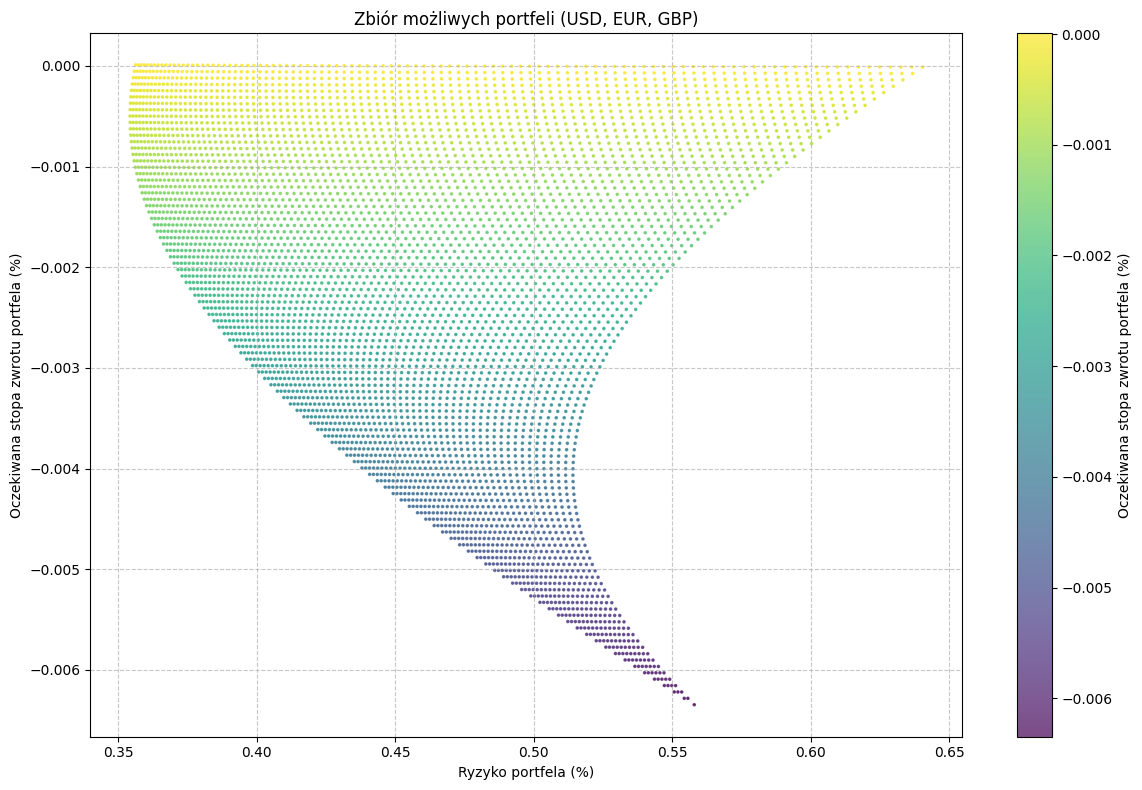

In [10]:
portfolio_results = []

# Define the step for weights
step = 0.01
# Define a small epsilon for floating point comparisons
epsilon = 1e-5 

num_portfolios_generated = 0

# Iterate through possible weights for USD
for w_usd_val in np.arange(0, 1 + epsilon, step):
    # Iterate through possible weights for EUR
    for w_eur_val in np.arange(0, 1 - w_usd_val + epsilon, step):
        w_gbp_val = 1 - w_usd_val - w_eur_val
        
        # Check if w_gbp_val is valid (approximately >= 0 and <= 1)
        # The loop condition for w_eur_val already ensures w_usd_val + w_eur_val <= 1, so w_gbp_val >= 0.
        # We just need to be careful with floating point arithmetic, so w_gbp_val can be slightly negative.
        if w_gbp_val >= -epsilon and w_gbp_val <= 1 + epsilon:
            # Ensure it's not negative due to precision, clip to 0 if very slightly negative
            if w_gbp_val < 0: w_gbp_val = 0.0

            weights = np.array([w_usd_val, w_eur_val, w_gbp_val])
            
            # Normalize weights to sum to exactly 1, in case of minor floating point sum deviations
            weights = weights / np.sum(weights)

            # Calculate portfolio return
            port_return = np.dot(weights, mean_returns)
            
            # Calculate portfolio variance and then risk (std deviation)
            port_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
            port_risk = np.sqrt(port_variance)
            
            portfolio_results.append((port_risk, port_return))
            num_portfolios_generated +=1

print(f"Wygenerowano {num_portfolios_generated} możliwych portfeli.")

# Convert results to a NumPy array for easier slicing
portfolio_results_array = np.array(portfolio_results)

# Plotting
plt.figure(figsize=(12, 8))
plt.scatter(portfolio_results_array[:, 0], portfolio_results_array[:, 1], c=portfolio_results_array[:, 1], cmap='viridis', marker='.', s=10, alpha=0.7)
plt.colorbar(label='Oczekiwana stopa zwrotu portfela (%)')
plt.title('Zbiór możliwych portfeli (USD, EUR, GBP)')
plt.xlabel('Ryzyko portfela (%)')
plt.ylabel('Oczekiwana stopa zwrotu portfela (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [2]:
import os

In [3]:
tickers = ['AAPL', 'MSFT', 'JPM']
csv_filename = 'stock_data_10_years_adj_close.csv'
force_download = False # Ustaw na True, aby wymusić pobranie danych z yfinance

end_date = datetime.today()
# Poprawka: Użyj daty, która na pewno jest dniem roboczym lub pozwól yfinance znaleźć najbliższy.
# Dla przykładu, jeśli dzisiaj jest 29.05.2025, to 10 lat temu to 29.05.2015.
# yfinance przesunie start i end na najbliższe dni handlowe.
start_date_calc = end_date - timedelta(days=10*365.25) # Około 10 lat

adj_close_prices = None

if not force_download and os.path.exists(csv_filename):
    print(f"Znaleziono plik CSV. Wczytywanie danych z: {csv_filename}")
    try:
        adj_close_prices = pd.read_csv(csv_filename, index_col=0, parse_dates=True)
        adj_close_prices.index = pd.to_datetime(adj_close_prices.index) # Upewnij się, że indeks to DatetimeIndex
        print("Dane zostały pomyślnie wczytane z pliku CSV.")
        if not all(ticker in adj_close_prices.columns for ticker in tickers):
            print("Ostrzeżenie: Kolumny w pliku CSV nie pasują do zdefiniowanych tickerów. Wymuszanie pobrania.")
            adj_close_prices = None
    except Exception as e:
        print(f"Błąd podczas wczytywania pliku CSV: {e}. Próba pobrania danych z yfinance.")
        adj_close_prices = None

if adj_close_prices is None:
    print(f"Pobieranie danych dla spółek: {', '.join(tickers)} z yfinance.")
    print(f"Okres: od {start_date_calc.strftime('%Y-%m-%d')} do {end_date.strftime('%Y-%m-%d')}")
    
    downloaded_successfully = False
    try:
        # Standardowe pobieranie; yfinance zwraca MultiIndex dla kolumn przy wielu tickerach
        downloaded_data = yf.download(tickers, start=start_date_calc, end=end_date, progress=False)
        
        if downloaded_data.empty:
            raise ValueError("yf.download zwrócił pusty DataFrame.")
            
        temp_prices_df = None
        # Prawidłowa obsługa MultiIndex
        if isinstance(downloaded_data.columns, pd.MultiIndex):
            if 'Adj Close' in downloaded_data.columns.levels[0]:
                temp_prices_df = downloaded_data['Adj Close'].copy()
            elif 'Close' in downloaded_data.columns.levels[0]: # Rezerwowe użycie 'Close'
                print("Nie znaleziono 'Adj Close' w MultiIndex, używam 'Close'.")
                temp_prices_df = downloaded_data['Close'].copy()
            else:
                raise ValueError("Ani 'Adj Close' ani 'Close' nie znaleziono w MultiIndex pobranych danych.")
        elif len(tickers) == 1: # Obsługa pojedynczego tickera (mniej prawdopodobne w tym scenariuszu)
            ticker_name = tickers[0]
            if 'Adj Close' in downloaded_data.columns:
                temp_prices_df = downloaded_data[['Adj Close']].copy()
                temp_prices_df.columns = [ticker_name]
            elif 'Close' in downloaded_data.columns:
                print(f"Nie znaleziono 'Adj Close' dla {ticker_name}, używam 'Close'.")
                temp_prices_df = downloaded_data[['Close']].copy()
                temp_prices_df.columns = [ticker_name]
        
        if temp_prices_df is None or temp_prices_df.empty:
            raise ValueError("Nie udało się wyodrębnić danych cenowych ('Adj Close' lub 'Close').")

        adj_close_prices = temp_prices_df
        adj_close_prices.columns = tickers # Upewnij się, że kolumny są nazwane tickerami

        # Obsługa brakujących wartości NaN
        if adj_close_prices.isnull().values.any():
            nan_counts_before = adj_close_prices.isnull().sum()
            print(f"Ostrzeżenie: Znaleziono brakujące wartości w pobranych danych cenowych. Liczba NaN przed usunięciem:\n{nan_counts_before[nan_counts_before > 0]}")
            adj_close_prices.dropna(inplace=True) # Usuwa wiersze, gdzie jakakolwiek wartość jest NaN
            print(f"Usunięto wiersze z wartościami NaN. Pozostało wierszy: {len(adj_close_prices)}")
        
        if adj_close_prices.empty:
            raise ValueError("DataFrame cen jest pusty po obsłużeniu brakujących wartości.")
        
        # Zapis pobranych danych do pliku CSV
        adj_close_prices.to_csv(csv_filename)
        print(f"Dane zostały pomyślnie pobrane i zapisane do pliku: {csv_filename}")
        downloaded_successfully = True

    except Exception as e_download:
        print(f"Wystąpił błąd podczas pobierania danych z yfinance: {e_download}")
        # adj_close_prices pozostanie None lub puste, jeśli wczytanie z CSV też się nie udało
    
    if not downloaded_successfully and (adj_close_prices is None or adj_close_prices.empty):
         print("Nie udało się pobrać ani wczytać danych. Używam danych przykładowych do demonstracji.")
         placeholder_dates = pd.date_range(start_date_calc, periods=252*10, freq='B') 
         # Bardziej realistyczne dane losowe (random walk)
         data_placeholder = {}
         for ticker in tickers:
             start_price = np.random.uniform(50, 200)
             daily_returns_placeholder = np.random.normal(loc=0.0005, scale=0.015, size=len(placeholder_dates))
             prices = start_price * (1 + daily_returns_placeholder).cumprod()
             data_placeholder[ticker] = prices
         adj_close_prices = pd.DataFrame(data_placeholder, index=placeholder_dates)
         print("Uwaga: Poniższa analiza bazuje na danych przykładowych.")



Znaleziono plik CSV. Wczytywanie danych z: stock_data_10_years_adj_close.csv
Dane zostały pomyślnie wczytane z pliku CSV.


In [52]:
tickers = ['AAPL', 'MSFT', 'JPM']
csv_filename_to_load = 'stock_data_10_years_adj_close.csv'
adj_close_prices = pd.read_csv(csv_filename_to_load, index_col=0, parse_dates=True)
adj_close_prices.index = pd.to_datetime(adj_close_prices.index)
    
adj_close_prices

,AAPL,MSFT,JPM
Date,,,
2015-06-01,29.236622,50.215942,40.952694
2015-06-02,29.106724,50.170361,40.683891
2015-06-03,29.142559,50.687096,40.623177
2015-06-04,28.972347,50.405945,40.198322
2015-06-05,28.813335,51.234253,40.007553
...,...,...,...
2025-05-21,202.089996,261.040009,452.570007
2025-05-22,201.360001,260.670013,454.859985
2025-05-23,195.270004,260.709991,450.179993


In [53]:
log_returns = np.log(1 + adj_close_prices.pct_change()) * 100
log_returns.dropna(inplace=True)

In [54]:
mean_log_returns = log_returns.mean()
std_log_returns = log_returns.std()
correlation_matrix_log_returns = log_returns.corr()
covariance_matrix_log_returns = log_returns.cov()

In [78]:
N = 252
mean_daily_log_returns_decimal = mean_log_returns / 100
annual_mean_log_returns_decimal = mean_daily_log_returns_decimal * N
annual_mean_log_returns_percentage = annual_mean_log_returns_decimal * 100
effective_annual_returns_decimal = np.exp(annual_mean_log_returns_decimal) - 1
effective_annual_returns_percent = effective_annual_returns_decimal * 100
std_daily_log_returns_decimal = std_log_returns / 100
annual_std_log_returns_decimal = std_daily_log_returns_decimal * np.sqrt(N)
annual_std_log_returns_percent = annual_std_log_returns_decimal * 100
daily_covariance_matrix_decimal_sq = covariance_matrix_log_returns / 10000
annual_covariance_matrix_decimal_sq = daily_covariance_matrix_decimal_sq * N

In [79]:
print("\n--- Średnie dzienne logarytmiczne stopy zwrotu (%) ---")

for ticker, value in mean_log_returns.items():
    print(f"{ticker}: {value:.4f}%")

print("\n--- Średnie roczne logarytmiczne stopy zwrotu (%) ---")
for ticker, value in annual_mean_log_returns_percentage.items():
    print(f"{ticker}: {value:.4f}%")


print("\n--- Odchylenia standardowe dziennych logarytmicznych stóp zwrotu (Ryzyko indywidualne) (%) ---")

for ticker, value in std_log_returns.items():
    print(f"{ticker}: {value:.4f}%")
    

print("\n--- Odchylenia standardowe rocznych logarytmicznych stóp zwrotu (Ryzyko indywidualne) (%) ---")
for ticker, value in annual_std_log_returns_percent.items():
    print(f"{ticker}: {value:.4f}%")


print("\n--- Macierz korelacji dziennych (i rocznych) logarytmicznych stóp zwrotu ---")
print(correlation_matrix_log_returns)



--- Średnie dzienne logarytmiczne stopy zwrotu (%) ---
AAPL: 0.0766%
MSFT: 0.0660%
JPM: 0.0960%

--- Średnie roczne logarytmiczne stopy zwrotu (%) ---
AAPL: 19.3036%
MSFT: 16.6230%
JPM: 24.1977%

--- Odchylenia standardowe dziennych logarytmicznych stóp zwrotu (Ryzyko indywidualne) (%) ---
AAPL: 1.8510%
MSFT: 1.7479%
JPM: 1.7137%

--- Odchylenia standardowe rocznych logarytmicznych stóp zwrotu (Ryzyko indywidualne) (%) ---
AAPL: 29.3830%
MSFT: 27.7466%
JPM: 27.2045%

--- Macierz korelacji dziennych (i rocznych) logarytmicznych stóp zwrotu ---
          AAPL      MSFT       JPM
AAPL  1.000000  0.435840  0.691388
MSFT  0.435840  1.000000  0.454023
JPM   0.691388  0.454023  1.000000


In [40]:
"""mean_log_returns = effective_annual_returns_percent
std_log_returns = annual_std_log_returns_percent"""

'mean_log_returns = effective_annual_returns_percent\nstd_log_returns = annual_std_log_returns_percent'

In [41]:
"""mean_returns_vector = mean_log_returns.values
covariance_matrix = covariance_matrix_log_returns.values"""

'mean_returns_vector = mean_log_returns.values\ncovariance_matrix = covariance_matrix_log_returns.values'

In [42]:
"""portfolio_risk_return_pairs = []
num_assets = 3
weight_step = 0.01 
epsilon_val = 1e-5
num_portfolios_generated_count = 0


# Pętla dla wag pierwszej spółki (AAPL)
for w1_val in np.arange(0, 1 + epsilon_val, weight_step):
    # Pętla dla wag drugiej spółki (MSFT)
    for w2_val in np.arange(0, 1 - w1_val + epsilon_val, weight_step):
        w3_val = 1 - w1_val - w2_val # Waga trzeciej spółki (JPM)
        
        # Sprawdzanie poprawności wag (czy w3_val nie jest ujemna przez błędy zaokrągleń)
        if w3_val >= -epsilon_val:
            if w3_val < 0: w3_val = 0.0 # Korekta, jeśli minimalnie ujemna
            if w3_val > 1: w3_val = 1.0 # Korekta, jeśli minimalnie > 1 (mniej prawdopodobne tutaj)


            current_weights = np.array([w1_val, w2_val, w3_val])
            
            # Normalizacja wag, aby suma była dokładnie 1 (ważne przy błędach zaokrągleń)
            current_weights_sum = np.sum(current_weights)
            if current_weights_sum > epsilon_val: # Uniknięcie dzielenia przez zero
                current_weights = current_weights / current_weights_sum
            else: # Jeśli suma wag jest bliska zeru (np. wszystkie wagi = 0), pomiń
                if not (abs(w1_val) < epsilon_val and abs(w2_val) < epsilon_val and abs(w3_val) < epsilon_val):
                    # To nie powinno się zdarzyć przy tej logice pętli, ale jako zabezpieczenie
                    print(f"Ostrzeżenie: suma wag bliska zeru dla: {current_weights}. Pomijanie.")
                continue # Pomiń portfel [0,0,0] lub inne problematyczne


            # Obliczanie oczekiwanej stopy zwrotu portfela
            portfolio_expected_return = np.dot(current_weights, mean_returns_vector)
            
            # Obliczanie wariancji i ryzyka (odchylenia standardowego) portfela
            portfolio_expected_variance = np.dot(current_weights.T, np.dot(covariance_matrix, current_weights))
            portfolio_expected_risk = np.sqrt(portfolio_expected_variance)
            
            portfolio_risk_return_pairs.append((portfolio_expected_risk, portfolio_expected_return))
            num_portfolios_generated_count += 1"""

'portfolio_risk_return_pairs = []\nnum_assets = 3\nweight_step = 0.01 \nepsilon_val = 1e-5\nnum_portfolios_generated_count = 0\n\n\n# Pętla dla wag pierwszej spółki (AAPL)\nfor w1_val in np.arange(0, 1 + epsilon_val, weight_step):\n    # Pętla dla wag drugiej spółki (MSFT)\n    for w2_val in np.arange(0, 1 - w1_val + epsilon_val, weight_step):\n        w3_val = 1 - w1_val - w2_val # Waga trzeciej spółki (JPM)\n        \n        # Sprawdzanie poprawności wag (czy w3_val nie jest ujemna przez błędy zaokrągleń)\n        if w3_val >= -epsilon_val:\n            if w3_val < 0: w3_val = 0.0 # Korekta, jeśli minimalnie ujemna\n            if w3_val > 1: w3_val = 1.0 # Korekta, jeśli minimalnie > 1 (mniej prawdopodobne tutaj)\n\n\n            current_weights = np.array([w1_val, w2_val, w3_val])\n            \n            # Normalizacja wag, aby suma była dokładnie 1 (ważne przy błędach zaokrągleń)\n            current_weights_sum = np.sum(current_weights)\n            if current_weights_sum > e

In [43]:
"""portfolio_details_list = [] 
for w1_val in np.arange(0, 1 + epsilon_val, weight_step):
    for w2_val in np.arange(0, 1 - w1_val + epsilon_val, weight_step):
        w3_val = 1 - w1_val - w2_val
        
        if w3_val >= -epsilon_val:
            if w3_val < 0: w3_val = 0.0
            if w3_val > 1: w3_val = 1.0

            current_weights = np.array([w1_val, w2_val, w3_val])
            current_weights_sum = np.sum(current_weights)
            if current_weights_sum > epsilon_val:
                current_weights = current_weights / current_weights_sum
            else: 
                if not (abs(w1_val) < epsilon_val and abs(w2_val) < epsilon_val and abs(w3_val) < epsilon_val):
                    print(f"Ostrzeżenie: suma wag bliska zeru dla: {current_weights}. Pomijanie.")
                continue

            portfolio_expected_return = np.dot(current_weights, mean_returns_vector)
            portfolio_expected_variance = np.dot(current_weights.T, np.dot(covariance_matrix, current_weights))
            # Dodano warunek sprawdzający, czy wariancja jest nieujemna
            if portfolio_expected_variance < 0: portfolio_expected_variance = 0.0
            portfolio_expected_risk = np.sqrt(portfolio_expected_variance)
            
            # ZMIANA: Zapisujemy ryzyko, zwrot ORAZ wagi
            portfolio_details_list.append((portfolio_expected_risk, portfolio_expected_return, current_weights.copy()))
            num_portfolios_generated_count += 1"""

'portfolio_details_list = [] \nfor w1_val in np.arange(0, 1 + epsilon_val, weight_step):\n    for w2_val in np.arange(0, 1 - w1_val + epsilon_val, weight_step):\n        w3_val = 1 - w1_val - w2_val\n        \n        if w3_val >= -epsilon_val:\n            if w3_val < 0: w3_val = 0.0\n            if w3_val > 1: w3_val = 1.0\n\n            current_weights = np.array([w1_val, w2_val, w3_val])\n            current_weights_sum = np.sum(current_weights)\n            if current_weights_sum > epsilon_val:\n                current_weights = current_weights / current_weights_sum\n            else: \n                if not (abs(w1_val) < epsilon_val and abs(w2_val) < epsilon_val and abs(w3_val) < epsilon_val):\n                    print(f"Ostrzeżenie: suma wag bliska zeru dla: {current_weights}. Pomijanie.")\n                continue\n\n            portfolio_expected_return = np.dot(current_weights, mean_returns_vector)\n            portfolio_expected_variance = np.dot(current_weights.T, np.dot

In [57]:
asset_mean_daily_log_returns_decimal = (mean_log_returns / 100).values
asset_daily_log_covariance_matrix_decimal_sq = (covariance_matrix_log_returns / 10000).values

portfolio_details_list = []
num_assets = len(tickers) # Powinno być 3 w Twoim przypadku
weight_step = 0.01
epsilon_val = 1e-5
num_portfolios_generated_count = 0 # Zresetuj licznik, jeśli pętla jest uruchamiana wielokrotnie

# Pętla dla wag pierwszej spółki (AAPL)
for w1_val in np.arange(0, 1 + epsilon_val, weight_step):
    # Pętla dla wag drugiej spółki (MSFT)
    for w2_val in np.arange(0, 1 - w1_val + epsilon_val, weight_step):
        w3_val = 1 - w1_val - w2_val # Waga trzeciej spółki (JPM)

        if w3_val >= -epsilon_val: # Sprawdzanie czy w3_val nie jest znacząco ujemna
            if w3_val < 0: w3_val = 0.0 # Korekta, jeśli minimalnie ujemna
            # if w3_val > 1: w3_val = 1.0 # Mniej prawdopodobne tutaj

            current_weights = np.array([w1_val, w2_val, w3_val])

            # Normalizacja wag, aby suma była dokładnie 1
            current_weights_sum = np.sum(current_weights)
            if current_weights_sum > epsilon_val: # Uniknięcie dzielenia przez zero
                current_weights = current_weights / current_weights_sum
            else:
                # Pomiń portfel [0,0,0] lub inne problematyczne (np. jeśli wszystkie wagi są bardzo bliskie zeru)
                # To zabezpieczenie jest bardziej na wypadek innych logik pętli; przy obecnej powinno być OK.
                if not (abs(w1_val) < epsilon_val and abs(w2_val) < epsilon_val and abs(w3_val) < epsilon_val):
                    print(f"Ostrzeżenie: suma wag bliska zeru dla: {current_weights}. Pomijanie.")
                continue

            # Obliczanie średniej dziennej logarytmicznej stopy zwrotu portfela (w formie dziesiętnej)
            port_daily_log_mean_dec = np.dot(current_weights, asset_mean_daily_log_returns_decimal)

            # Obliczanie dziennej wariancji logarytmicznej portfela (w formie dziesiętnej do kwadratu)
            port_daily_log_var_dec_sq = np.dot(current_weights.T, np.dot(asset_daily_log_covariance_matrix_decimal_sq, current_weights))
            if port_daily_log_var_dec_sq < 0: # Zabezpieczenie przed pierwiastkowaniem ujemnej liczby (błędy numeryczne)
                port_daily_log_var_dec_sq = 0.0
            port_daily_log_std_dev_dec = np.sqrt(port_daily_log_var_dec_sq)

            # Annualizacja parametrów logarytmicznych portfela
            port_annual_log_mean_dec = port_daily_log_mean_dec * N
            port_annual_log_std_dev_dec = port_daily_log_std_dev_dec * np.sqrt(N)

            # Oczekiwana stopa zwrotu portfela: Efektywna roczna stopa zwrotu (%)
            # Obliczana na podstawie rocznej średniej logarytmicznej stopy zwrotu portfela
            portfolio_expected_return_percent = (np.exp(port_annual_log_mean_dec) - 1) * 100

            # Ryzyko portfela: Roczne odchylenie standardowe logarytmicznych stóp zwrotu portfela (%)
            portfolio_risk_percent = port_annual_log_std_dev_dec * 100
            
            portfolio_details_list.append((portfolio_risk_percent, portfolio_expected_return_percent, current_weights.copy()))
            num_portfolios_generated_count += 1


In [58]:
portfolio_results_as_array = np.array([(p[0], p[1]) for p in portfolio_details_list])

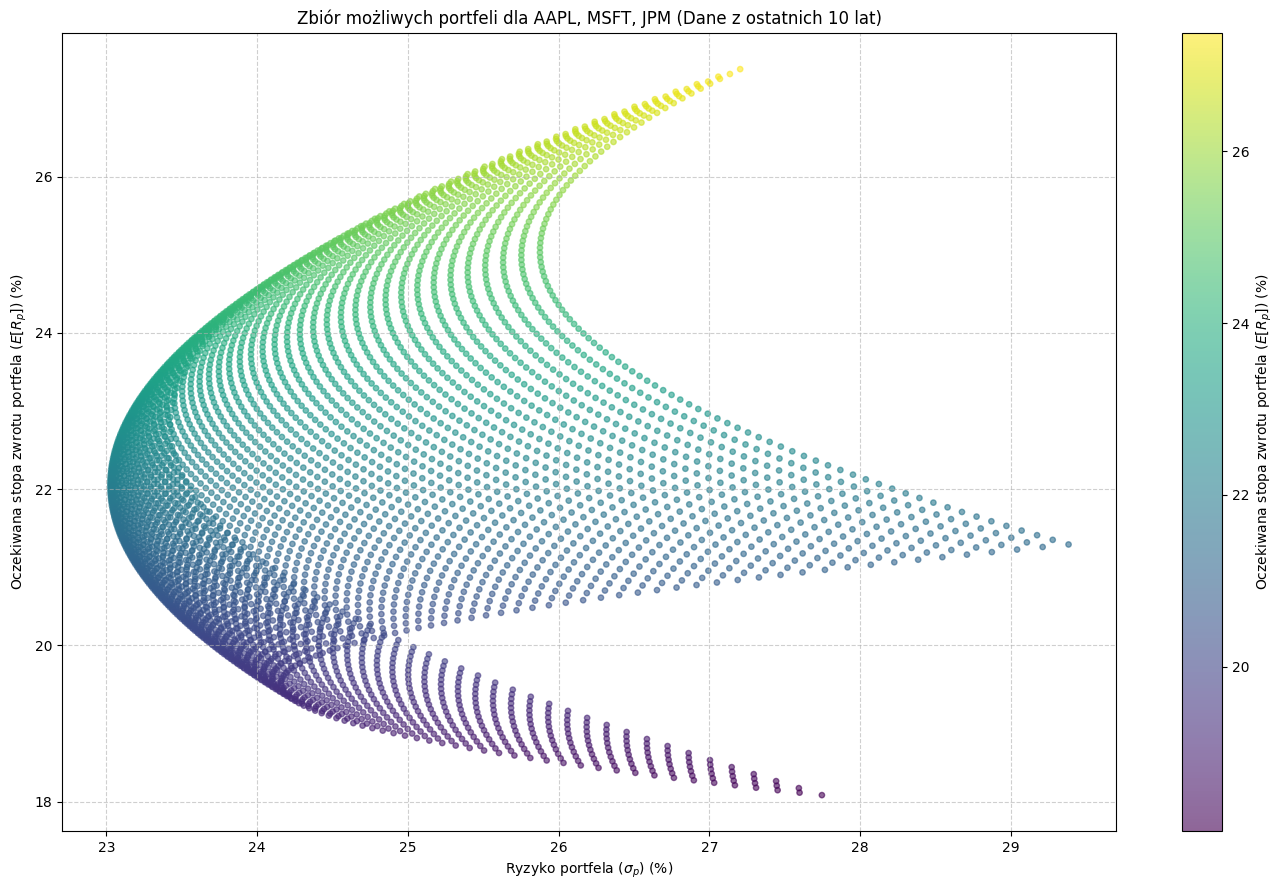

In [59]:
    
plt.figure(figsize=(14, 9))
plt.scatter(portfolio_results_as_array[:, 0], portfolio_results_as_array[:, 1], 
            c=portfolio_results_as_array[:, 1], 
            cmap='viridis', marker='o', s=15, alpha=0.6)
plt.colorbar(label='Oczekiwana stopa zwrotu portfela ($E[R_p]$) (%)')
plt.title(f'Zbiór możliwych portfeli dla {", ".join(tickers)} (Dane z ostatnich 10 lat)')
plt.xlabel('Ryzyko portfela ($\\sigma_p$) (%)')
plt.ylabel('Oczekiwana stopa zwrotu portfela ($E[R_p]$) (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Portfel o minimalnym ryzyku

In [60]:
min_risk_idx = np.argmin(portfolio_results_as_array[:, 0])
mvp_risk, mvp_return, mvp_weights = portfolio_details_list[min_risk_idx]

print("\n--- Portfel Minimalnego Ryzyka ---")
print(f"Oczekiwana stopa zwrotu: {mvp_return:.4f}%")
print(f"Ryzyko (odch. std.): {mvp_risk:.4f}%")
print("Wagi portfela MVP:")
for ticker, weight in zip(tickers, mvp_weights):
    print(f"  {ticker}: {weight*100:.2f}%")


--- Portfel Minimalnego Ryzyka ---
Oczekiwana stopa zwrotu: 22.0936%
Ryzyko (odch. std.): 23.0253%
Wagi portfela MVP:
  AAPL: 20.00%
  MSFT: 43.00%
  JPM: 37.00%


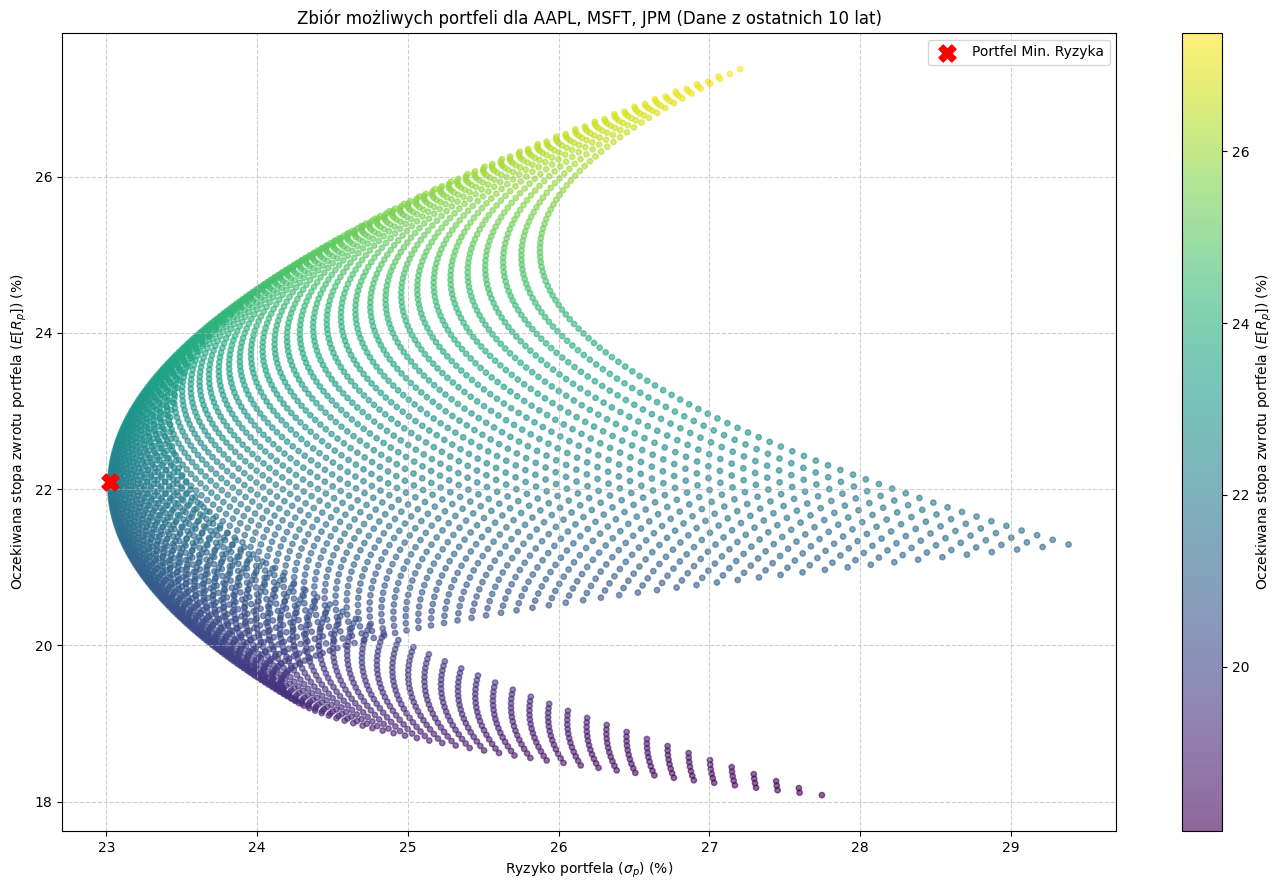

In [65]:
    
plt.figure(figsize=(14, 9))
plt.scatter(portfolio_results_as_array[:, 0], portfolio_results_as_array[:, 1], 
            c=portfolio_results_as_array[:, 1], 
            cmap='viridis', marker='o', s=15, alpha=0.6)
plt.colorbar(label='Oczekiwana stopa zwrotu portfela ($E[R_p]$) (%)')
plt.scatter(mvp_risk, mvp_return, marker='X', color='red', s=150, label='Portfel Min. Ryzyka', zorder=5)
plt.title(f'Zbiór możliwych portfeli dla {", ".join(tickers)} (Dane z ostatnich 10 lat)')
plt.xlabel('Ryzyko portfela ($\\sigma_p$) (%)')
plt.ylabel('Oczekiwana stopa zwrotu portfela ($E[R_p]$) (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [66]:
target_return = 26
tolerance = 3 * 10e-3

candidate_portfolios = []
for risk, ret, weights in portfolio_details_list:
    if abs(ret - target_return) <= tolerance:
        candidate_portfolios.append({'risk': risk, 'return': ret, 'weights': weights})

efficient_portfolio_for_target_return = min(candidate_portfolios, key=lambda x: x['risk'])

eptr_risk = efficient_portfolio_for_target_return['risk']
eptr_return = efficient_portfolio_for_target_return['return']
eptr_weights = efficient_portfolio_for_target_return['weights']

In [67]:
print("\n--- Portfel Min. Ryzyka dla ustalonej stopy zwrotu ---")
print(f"Docelowa stopa zwrotu: {target_return:.4f}% (w ramach tolerancji +/- {tolerance}%)")
print(f"Rzeczywista oczekiwana stopa zwrotu portfela: {eptr_return:.4f}%")
print(f"Minimalne ryzyko (odch. std.) dla tej stopy zwrotu: {eptr_risk:.4f}%")
print("Wagi portfela:")
for ticker, weight in zip(tickers, eptr_weights):
    print(f"  {ticker}: {weight*100:.2f}%")



--- Portfel Min. Ryzyka dla ustalonej stopy zwrotu ---
Docelowa stopa zwrotu: 26.0000% (w ramach tolerancji +/- 0.03%)
Rzeczywista oczekiwana stopa zwrotu portfela: 25.9712%
Minimalne ryzyko (odch. std.) dla tej stopy zwrotu: 25.3346%
Wagi portfela:
  AAPL: 1.00%
  MSFT: 14.00%
  JPM: 85.00%


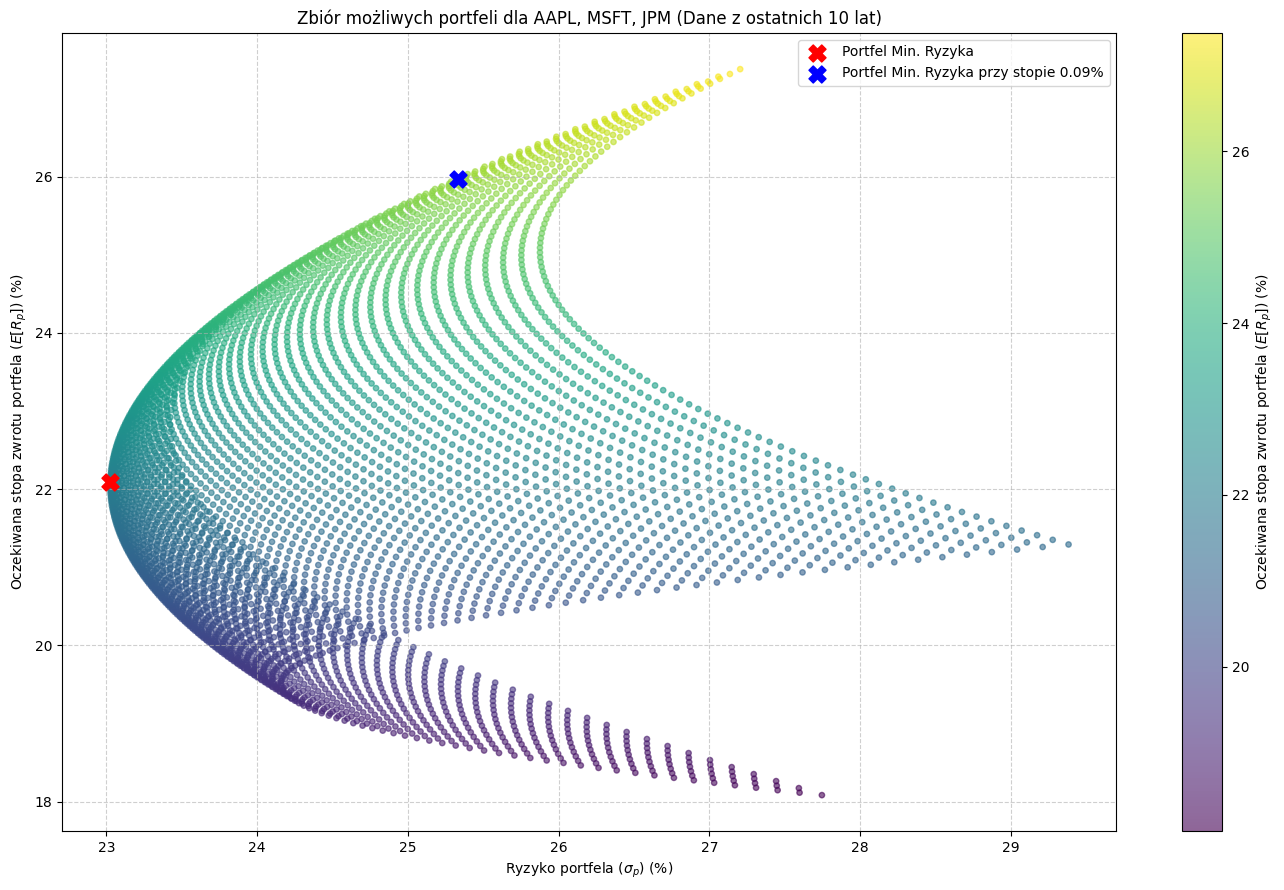

In [69]:
plt.figure(figsize=(14, 9))
plt.scatter(portfolio_results_as_array[:, 0], portfolio_results_as_array[:, 1], 
            c=portfolio_results_as_array[:, 1], 
            cmap='viridis', marker='o', s=15, alpha=0.6)
plt.colorbar(label='Oczekiwana stopa zwrotu portfela ($E[R_p]$) (%)')
plt.scatter(mvp_risk, mvp_return, marker='X', color='red', s=150, label='Portfel Min. Ryzyka', zorder=5)
plt.scatter(eptr_risk, eptr_return, marker='X', color='blue', s=150, label='Portfel Min. Ryzyka przy stopie 0.09%', zorder=5)
plt.title(f'Zbiór możliwych portfeli dla {", ".join(tickers)} (Dane z ostatnich 10 lat)')
plt.xlabel('Ryzyko portfela ($\\sigma_p$) (%)')
plt.ylabel('Oczekiwana stopa zwrotu portfela ($E[R_p]$) (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()


Generowanie portfeli (na podstawie dziennych parametrów, krok wag: 0.01)...
Wygenerowano 5151 możliwych portfeli (statystyki dzienne).

--- Portfel Styczny (Rynkowy) - maksymalizujący wskaźnik Sharpe'a (na bazie rocznych statystyk) ---
Roczna oczekiwana stopa zwrotu: 26.13%
Roczne ryzyko (odch. std.): 25.51%
Wskaźnik Sharpe'a: 0.8479
Wagi portfela:
  AAPL: 0.00%
  MSFT: 13.00%
  JPM: 87.00%


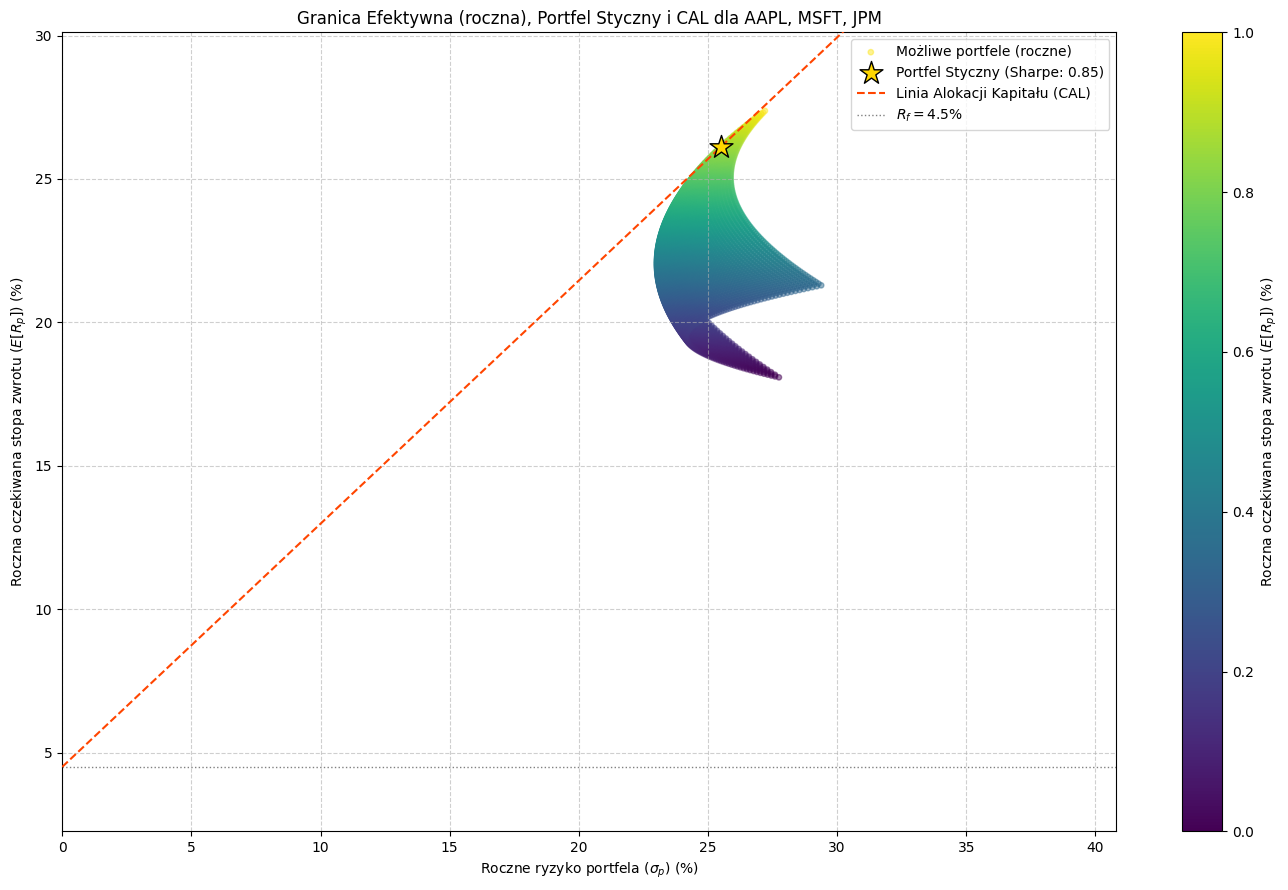

Wykres z Portfelem Stycznym (rocznym, metoda B) został zapisany jako 'markowitz_tangency_annual_v2.png'


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Te zmienne są używane w Twojej pętli i reprezentują statystyki DZIENNE
mean_log_returns_daily_pct = log_returns.mean() # Średnie dzienne log zwroty w %
covariance_matrix_daily_pct_sq = log_returns.cov() # Dzienna kowariancja, elementy w (%^2)

# Wektory używane w pętli do obliczania charakterystyk portfela
# Ważne: mean_returns_vector będzie zawierał średnie DZIENNE log zwroty w %
# covariance_matrix będzie DZIENNĄ macierzą kowariancji w (%^2)
mean_returns_vector_for_loop = mean_log_returns_daily_pct.values
covariance_matrix_for_loop = covariance_matrix_daily_pct_sq.values

# Twoja pętla generująca portfele (zgodnie z Twoim kodem)
# Przechowuje (dzienne_ryzyko_log_proc, dzienna_stopa_zwrotu_log_proc, wagi)
portfolio_details_list_daily = [] # Zmieniono nazwę dla jasności
num_assets = len(tickers)
weight_step = 0.01 
epsilon_val = 1e-5
num_portfolios_generated_count = 0

print(f"\nGenerowanie portfeli (na podstawie dziennych parametrów, krok wag: {weight_step})...")
for w1_val in np.arange(0, 1 + epsilon_val, weight_step):
    for w2_val in np.arange(0, 1 - w1_val + epsilon_val, weight_step):
        w3_val = 1 - w1_val - w2_val
        if w3_val >= -epsilon_val:
            if w3_val < 0: w3_val = 0.0
            if w3_val > 1: w3_val = 1.0

            current_weights = np.array([w1_val, w2_val, w3_val])
            current_weights_sum = np.sum(current_weights)
            if current_weights_sum > epsilon_val:
                current_weights = current_weights / current_weights_sum
            else: 
                if not (abs(w1_val) < epsilon_val and abs(w2_val) < epsilon_val and abs(w3_val) < epsilon_val):
                    print(f"Ostrzeżenie: suma wag bliska zeru dla: {current_weights}. Pomijanie.")
                continue
            
            # Obliczanie DZIENNEJ logarytmicznej stopy zwrotu portfela (w %)
            daily_portfolio_log_return_pct = np.dot(current_weights, mean_returns_vector_for_loop)
            
            # Obliczanie DZIENNEJ wariancji (w %^2) i ryzyka (w %) portfela
            daily_portfolio_variance_pct_sq = np.dot(current_weights.T, np.dot(covariance_matrix_for_loop, current_weights))
            if daily_portfolio_variance_pct_sq < 0: daily_portfolio_variance_pct_sq = 0.0
            daily_portfolio_log_risk_pct = np.sqrt(daily_portfolio_variance_pct_sq)
            
            portfolio_details_list_daily.append((daily_portfolio_log_risk_pct, daily_portfolio_log_return_pct, current_weights.copy()))
            num_portfolios_generated_count += 1
print(f"Wygenerowano {num_portfolios_generated_count} możliwych portfeli (statystyki dzienne).")
# --- Koniec Twojego istniejącego kodu generowania portfeli ---


# --- NOWY KOD: Annualizacja statystyk portfeli i znalezienie portfela stycznego ---
N = 252  # Liczba dni handlowych w roku
annual_risk_free_rate = 0.045  # Roczna stopa wolna od ryzyka (5% = 0.05)

annualized_portfolio_details_for_tangency = []
if portfolio_details_list_daily: # Sprawdzenie, czy lista nie jest pusta
    for daily_log_risk_pct, daily_log_return_pct, weights_arr in portfolio_details_list_daily:
        # Konwersja dziennych logarytmicznych stóp zwrotu i ryzyka z % na wartości dziesiętne
        daily_log_return_decimal = daily_log_return_pct / 100
        daily_log_risk_decimal = daily_log_risk_pct / 100
        
        # Annualizacja stopy zwrotu (efektywna roczna stopa zwrotu)
        effective_annual_return_decimal = np.exp(daily_log_return_decimal * N) - 1
        
        # Annualizacja ryzyka (roczne odchylenie standardowe)
        annual_risk_decimal = daily_log_risk_decimal * np.sqrt(N)
        
        # Obliczanie wskaźnika Sharpe'a
        sharpe_ratio_val = -np.inf # Domyślnie, jeśli ryzyko jest zbyt małe
        if annual_risk_decimal > epsilon_val: # Uniknięcie dzielenia przez zero/bardzo małe ryzyko
            sharpe_ratio_val = (effective_annual_return_decimal - annual_risk_free_rate) / annual_risk_decimal
            
        annualized_portfolio_details_for_tangency.append({
            'risk_dec': annual_risk_decimal,
            'return_dec': effective_annual_return_decimal,
            'weights': weights_arr,
            'sharpe': sharpe_ratio_val
        })
else:
    print("Brak wygenerowanych portfeli dziennych do annualizacji.")

tangency_portfolio_stats = None
if annualized_portfolio_details_for_tangency:
    valid_sharpe_portfolios = [p for p in annualized_portfolio_details_for_tangency if p['sharpe'] != -np.inf]
    if valid_sharpe_portfolios:
        tangency_portfolio_stats = max(valid_sharpe_portfolios, key=lambda x: x['sharpe'])
        
        print("\n--- Portfel Styczny (Rynkowy) - maksymalizujący wskaźnik Sharpe'a (na bazie rocznych statystyk) ---")
        print(f"Roczna oczekiwana stopa zwrotu: {tangency_portfolio_stats['return_dec']*100:.2f}%")
        print(f"Roczne ryzyko (odch. std.): {tangency_portfolio_stats['risk_dec']*100:.2f}%")
        print(f"Wskaźnik Sharpe'a: {tangency_portfolio_stats['sharpe']:.4f}")
        print("Wagi portfela:")
        for ticker_name, weight_val in zip(tickers, tangency_portfolio_stats['weights']):
            print(f"  {ticker_name}: {weight_val*100:.2f}%")
    else:
        print("Nie znaleziono portfeli z poprawnym wskaźnikiem Sharpe'a do wyznaczenia portfela stycznego.")
else:
    print("Brak zannualizowanych portfeli do analizy.")

# --- Rysowanie wykresu (teraz z rocznymi wartościami) ---
if annualized_portfolio_details_for_tangency:
    plot_risks_annual_pct = np.array([p['risk_dec'] * 100 for p in annualized_portfolio_details_for_tangency])
    plot_returns_annual_pct = np.array([p['return_dec'] * 100 for p in annualized_portfolio_details_for_tangency])
    
    plt.figure(figsize=(14, 9))
    # Chmura portfeli (roczne ryzyko vs roczny zwrot)
    plt.scatter(plot_risks_annual_pct, plot_returns_annual_pct, 
                c=plot_returns_annual_pct, 
                cmap='viridis', marker='o', s=15, alpha=0.5, label='Możliwe portfele (roczne)')

    if tangency_portfolio_stats:
        tp_risk_pct = tangency_portfolio_stats['risk_dec'] * 100
        tp_return_pct = tangency_portfolio_stats['return_dec'] * 100
        
        # Zaznaczenie Portfela Stycznego
        plt.scatter(tp_risk_pct, tp_return_pct, 
                    marker='*', color='gold', s=300, edgecolors='black',
                    label=f"Portfel Styczny (Sharpe: {tangency_portfolio_stats['sharpe']:.2f})", zorder=6)
        
        # Rysowanie Linii Alokacji Kapitału (CAL)
        # Linia od (0, Rf) przez portfel styczny
        plt.plot([0, tp_risk_pct, tp_risk_pct * 1.5], # Rysujemy trochę dalej dla wizualizacji
                 [annual_risk_free_rate * 100, tp_return_pct, 
                  annual_risk_free_rate * 100 + tangency_portfolio_stats['sharpe'] * tp_risk_pct * 1.5], 
                 linestyle='--', color='orangered', label='Linia Alokacji Kapitału (CAL)', zorder=5)

    plt.colorbar(label='Roczna oczekiwana stopa zwrotu ($E[R_p]$) (%)')
    plt.title(f'Granica Efektywna (roczna), Portfel Styczny i CAL dla {", ".join(tickers)}')
    plt.xlabel('Roczne ryzyko portfela ($\\sigma_p$) (%)')
    plt.ylabel('Roczna oczekiwana stopa zwrotu ($E[R_p]$) (%)')
    plt.axhline(annual_risk_free_rate * 100, color='grey', linestyle=':', lw=1, label=f'$R_f = {annual_risk_free_rate*100:.1f}\\%$')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    min_plot_risk_val = 0
    # Ustalanie zakresów osi, aby Rf i portfel styczny były dobrze widoczne
    if plot_risks_annual_pct.size > 0:
        max_plot_risk_val = max(np.max(plot_risks_annual_pct) * 1.1, (tangency_portfolio_stats['risk_dec'] * 100 * 1.6) if tangency_portfolio_stats else 30)
        all_returns_for_plot = np.append(plot_returns_annual_pct, annual_risk_free_rate * 100)
        if tangency_portfolio_stats:
            all_returns_for_plot = np.append(all_returns_for_plot, tangency_portfolio_stats['return_dec'] * 100)
        
        min_plot_return_val = min(np.min(all_returns_for_plot) * 0.9 if np.min(all_returns_for_plot) <0 else np.min(all_returns_for_plot)*0.5, annual_risk_free_rate * 100 * 0.8)
        max_plot_return_val = max(np.max(all_returns_for_plot) * 1.1, annual_risk_free_rate * 100 * 1.2)
    else: # Domyślne wartości, jeśli brak danych
        max_plot_risk_val = 30
        min_plot_return_val = 0
        max_plot_return_val = 20

    plt.xlim(left=min_plot_risk_val, right=max_plot_risk_val)
    plt.ylim(bottom=min_plot_return_val, top=max_plot_return_val)

    plt.tight_layout()
    plot_filename_tangency_annual_v2 = 'markowitz_tangency_annual_v2.png'
    plt.savefig(plot_filename_tangency_annual_v2)
    plt.show()
    print(f"Wykres z Portfelem Stycznym (rocznym, metoda B) został zapisany jako '{plot_filename_tangency_annual_v2}'")
else:
    print("Nie można wygenerować wykresu, ponieważ lista `annualized_portfolio_details_for_tangency` jest pusta.")

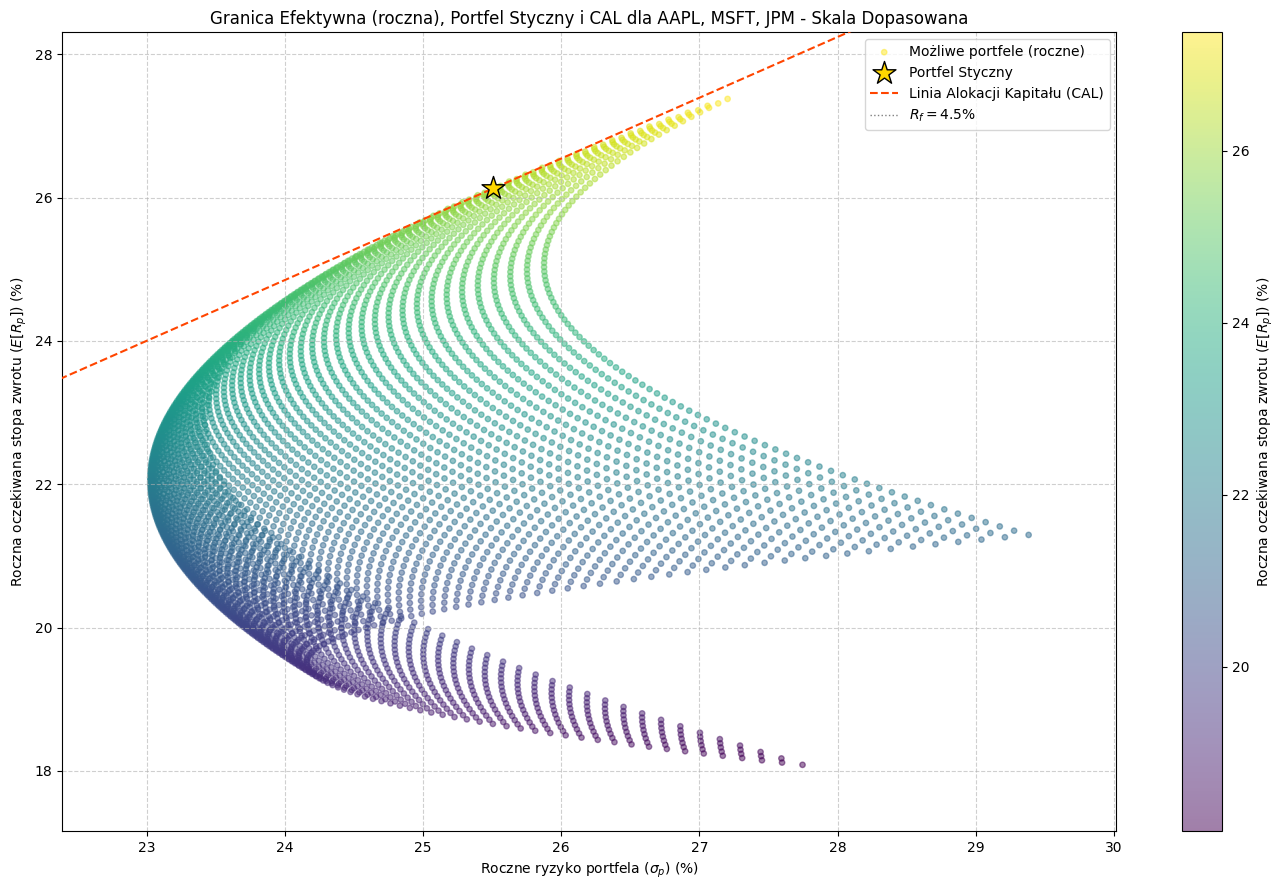

Wykres z Portfelem Stycznym (skala dopasowana do chmury) został zapisany jako 'markowitz_tangency_custom_scale.png'


In [74]:
if 'annualized_portfolio_details_for_tangency' in locals() and annualized_portfolio_details_for_tangency:
    # Przygotowanie danych do rysowania (ryzyko i zwrot w procentach)
    plot_risks_annual_pct = np.array([p['risk_dec'] * 100 for p in annualized_portfolio_details_for_tangency])
    plot_returns_annual_pct = np.array([p['return_dec'] * 100 for p in annualized_portfolio_details_for_tangency])
    
    plt.figure(figsize=(14, 9))
    plt.scatter(plot_risks_annual_pct, plot_returns_annual_pct, 
                c=plot_returns_annual_pct, 
                cmap='viridis', marker='o', s=15, alpha=0.5, label='Możliwe portfele (roczne)')
    plt.colorbar(label='Roczna oczekiwana stopa zwrotu ($E[R_p]$) (%)')

    if 'tangency_portfolio_stats' in locals() and tangency_portfolio_stats:
        tp_risk_pct = tangency_portfolio_stats['risk_dec'] * 100
        tp_return_pct = tangency_portfolio_stats['return_dec'] * 100
        
        plt.scatter(tp_risk_pct, tp_return_pct, 
                    marker='*', color='gold', s=300, edgecolors='black',
                    label=f"Portfel Styczny", zorder=6) # zorder wyżej
        
        # Rysowanie Linii Alokacji Kapitału (CAL)
        # Aby CAL była widoczna w nowej skali, możemy ją ograniczyć lub dostosować jej zakres
        # Określamy punkty dla CAL: (0, Rf) oraz (tp_risk_pct, tp_return_pct)
        # Wykres CAL może wyjść poza nowe, ciaśniejsze granice, co jest oczekiwane
        # dla tej zmiany. Rysujemy ją jednak, aby pokazać jej kierunek.
        
        # Obliczamy punkty na linii CAL, które mogą być widoczne
        cal_x_points = np.array([0, tp_risk_pct, tp_risk_pct * 1.5]) # Można dostosować zakres CAL
        cal_y_points = annual_risk_free_rate * 100 + tangency_portfolio_stats['sharpe'] * (cal_x_points/100 * np.sqrt(N)) * 100 # To nie jest poprawne, Sharpe jest z rocznego ryzyka
        # Poprawna linia CAL z rocznym ryzykiem
        cal_y_points_correct = annual_risk_free_rate * 100 + tangency_portfolio_stats['sharpe'] * cal_x_points


        plt.plot(cal_x_points, cal_y_points_correct, 
                 linestyle='--', color='orangered', label='Linia Alokacji Kapitału (CAL)', zorder=5)

    plt.title(f'Granica Efektywna (roczna), Portfel Styczny i CAL dla {", ".join(tickers)} - Skala Dopasowana')
    plt.xlabel('Roczne ryzyko portfela ($\\sigma_p$) (%)')
    plt.ylabel('Roczna oczekiwana stopa zwrotu ($E[R_p]$) (%)')
    
    # Linia stopy wolnej od ryzyka - rysujemy ją, ale może być poza nowymi granicami Y
    plt.axhline(annual_risk_free_rate * 100, color='grey', linestyle=':', lw=1, label=f'$R_f = {annual_risk_free_rate*100:.1f}\\%$')
    
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # --- NOWA LOGIKA USTAWIANIA LIMITÓW OSI ---
    if plot_risks_annual_pct.size > 0 and plot_returns_annual_pct.size > 0:
        # Określ granice na podstawie chmury portfeli
        min_r_cloud = np.min(plot_risks_annual_pct)
        max_r_cloud = np.max(plot_risks_annual_pct)
        min_ret_cloud = np.min(plot_returns_annual_pct)
        max_ret_cloud = np.max(plot_returns_annual_pct)
        
        # Dodaj margines
        x_padding = (max_r_cloud - min_r_cloud) * 0.10  # Zwiększony margines
        y_padding = (max_ret_cloud - min_ret_cloud) * 0.10  # Zwiększony margines
        
        x_lower = min_r_cloud - x_padding
        x_upper = max_r_cloud + x_padding
        y_lower = min_ret_cloud - y_padding
        y_upper = max_ret_cloud + y_padding

        # Upewnij się, że portfel styczny jest widoczny, jeśli istnieje
        if 'tangency_portfolio_stats' in locals() and tangency_portfolio_stats:
            tp_risk_pct = tangency_portfolio_stats['risk_dec'] * 100
            tp_return_pct = tangency_portfolio_stats['return_dec'] * 100
            # Rozszerz granice, jeśli portfel styczny jest poza obecnymi granicami chmury + padding
            x_lower = min(x_lower, tp_risk_pct - (max_r_cloud - min_r_cloud) * 0.02) # Mniejszy padding od TP
            x_upper = max(x_upper, tp_risk_pct + (max_r_cloud - min_r_cloud) * 0.02)
            y_lower = min(y_lower, tp_return_pct - (max_ret_cloud - min_ret_cloud) * 0.02)
            y_upper = max(y_upper, tp_return_pct + (max_ret_cloud - min_ret_cloud) * 0.02)

        # Opcjonalnie: Możesz chcieć, aby oś Y zawsze pokazywała stopę wolną od ryzyka, jeśli jest blisko
        # y_lower = min(y_lower, annual_risk_free_rate * 100 - y_padding)
        # Opcjonalnie: Oś X może zaczynać się blisko zera, jeśli portfele mają niskie ryzyko
        # x_lower = max(0, x_lower) # Jeśli nie chcesz ujemnego ryzyka na osi (co nie powinno się zdarzyć)


        plt.xlim(left=x_lower, right=x_upper)
        plt.ylim(bottom=y_lower, top=y_upper)
        
    else: # Domyślne limity, jeśli brak danych portfelowych
        plt.xlim(left=0, right=30)
        plt.ylim(bottom=0, top=20)
        
    plt.legend() # Przesunięte po ustawieniu limitów, aby legenda nie wpływała na auto-skalowanie, jeśli było
    plt.tight_layout()
    
    plot_filename_tangency_custom_scale = 'markowitz_tangency_custom_scale.png'
    plt.savefig(plot_filename_tangency_custom_scale)
    plt.show()
    print(f"Wykres z Portfelem Stycznym (skala dopasowana do chmury) został zapisany jako '{plot_filename_tangency_custom_scale}'")

else:
    print("Nie można wygenerować wykresu, ponieważ lista 'annualized_portfolio_details_for_tangency' jest pusta.")

In [75]:

if 'tangency_portfolio_stats' in locals() and tangency_portfolio_stats is not None:
    print("\n--- Podsumowanie Portfela Rynkowego (Stycznego) ---")
    
    # Roczna oczekiwana stopa zwrotu
    annual_return_percent = tangency_portfolio_stats['return_dec'] * 100
    print(f"Oczekiwana roczna stopa zwrotu: {annual_return_percent:.2f}%")
    
    # Roczne ryzyko (odchylenie standardowe)
    annual_risk_percent = tangency_portfolio_stats['risk_dec'] * 100
    print(f"Roczne ryzyko (odchylenie standardowe): {annual_risk_percent:.2f}%")
    
    # Wskaźnik Sharpe'a
    sharpe_ratio = tangency_portfolio_stats['sharpe']
    print(f"Wskaźnik Sharpe'a: {sharpe_ratio:.4f}")
    
    # Wagi portfela
    print("Wagi portfela:")
    if 'tickers' in locals() and len(tickers) == len(tangency_portfolio_stats['weights']):
        for ticker_name, weight_val in zip(tickers, tangency_portfolio_stats['weights']):
            print(f"  {ticker_name}: {weight_val*100:.2f}%")
    else:
        print("  Nie można wyświetlić wag, brak informacji o tickerach lub niezgodna liczba wag.")
else:
    print("\nBrak danych dla portfela stycznego (rynkowego) do wyświetlenia podsumowania.")
    print("Upewnij się, że poprzednie kroki obliczeniowe zostały wykonane poprawnie.")


--- Podsumowanie Portfela Rynkowego (Stycznego) ---
Oczekiwana roczna stopa zwrotu: 26.13%
Roczne ryzyko (odchylenie standardowe): 25.51%
Wskaźnik Sharpe'a: 0.8479
Wagi portfela:
  AAPL: 0.00%
  MSFT: 13.00%
  JPM: 87.00%


In [56]:
from scipy.stats import norm


In [57]:
print(covariance_matrix_log_returns)

          AAPL      MSFT       JPM
AAPL  3.426036  1.410044  2.193098
MSFT  1.410044  3.055054  1.359964
JPM   2.193098  1.359964  2.936839


In [58]:
wagi_mr = np.array([0.2, 0.43, 0.37])
wagi_mrp = np.array([0, 0.15, 0.85])
wagi_r = np.array([0, 0.12, 0.88])

### Portfel minimalnego ryzyka

In [92]:
# Oblicz wariancję portfela
portfolio_variance = np.dot(wagi_mr.T, np.dot(covariance_matrix_log_returns, wagi_mr))

# Oblicz odchylenie standardowe portfela
portfolio_std_dev = np.sqrt(portfolio_variance)

# Oblicz średni zwrot z portfela
portfolio_mean_return = np.dot(wagi_mr, log_returns.mean())

# Funkcja do obliczania VaR
def calculate_var(mean_return, std_dev, confidence_level):
    z_score = norm.ppf(1 - confidence_level)
    var = mean_return + z_score * std_dev
    return var

# Oblicz VaR dla poziomów ufności 95% i 99%
var_95 = calculate_var(portfolio_mean_return, portfolio_std_dev, 0.95)
var_99 = calculate_var(portfolio_mean_return, portfolio_std_dev, 0.99)

print(f"VaR 95%: {var_95:.4f}")
print(f"VaR 99%: {var_99:.4f}")

VaR 95%: -2.3066
VaR 99%: -3.2951


### Portfel minimalnego ryzyka dla ustalonej stopy zwrotu

In [98]:
# Oblicz wariancję portfela
portfolio_variance = np.dot(wagi_mrp.T, np.dot(covariance_matrix_log_returns, wagi_mrp))

# Oblicz odchylenie standardowe portfela
portfolio_std_dev = np.sqrt(portfolio_variance)

# Oblicz średni zwrot z portfela
portfolio_mean_return = np.dot(wagi_mrp, log_returns.mean())

# Funkcja do obliczania VaR
def calculate_var(mean_return, std_dev, confidence_level):
    z_score = norm.ppf(1 - confidence_level)
    var = mean_return + z_score * std_dev
    return var

# Oblicz VaR dla poziomów ufności 95% i 99%
var_95 = calculate_var(portfolio_mean_return, portfolio_std_dev, 0.95)
var_99 = calculate_var(portfolio_mean_return, portfolio_std_dev, 0.99)

print(f"VaR 95%: {var_95:.4f}")
print(f"VaR 99%: {var_99:.4f}")

VaR 95%: -2.5286
VaR 99%: -3.6142


### Portfel rynkowy

In [99]:
# Oblicz wariancję portfela
portfolio_variance = np.dot(wagi_r.T, np.dot(covariance_matrix_log_returns, wagi_r))

# Oblicz odchylenie standardowe portfela
portfolio_std_dev = np.sqrt(portfolio_variance)

# Oblicz średni zwrot z portfela
portfolio_mean_return = np.dot(wagi_r, log_returns.mean())

# Funkcja do obliczania VaR
def calculate_var(mean_return, std_dev, confidence_level):
    z_score = norm.ppf(1 - confidence_level)
    var = mean_return + z_score * std_dev
    return var

# Oblicz VaR dla poziomów ufności 95% i 99%
var_95 = calculate_var(portfolio_mean_return, portfolio_std_dev, 0.95)
var_99 = calculate_var(portfolio_mean_return, portfolio_std_dev, 0.99)

print(f"VaR 95%: {var_95:.4f}")
print(f"VaR 99%: {var_99:.4f}")

VaR 95%: -2.5626
VaR 99%: -3.6627
